# 05 — Combined Evaluation

**Purpose:** Evaluate all three models on the test term (latest term in DB).  
**Input:** `.pkl` files from `models/`, `*_test.csv` files from `data/processed/`  
**Output:** `models/eval_results.json`

| Block | What |
|-------|------|
| 1 | Setup + derive test term dynamically |
| 2 | Load models + test data |
| 3 | Run predictions |
| 4 | Individual model metrics |
| 5 | System score (0–3) |
| 6 | Conditional evaluations |
| 7 | Summary + write eval_results.json |

---
## Block 1 — Setup

In [1]:
import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, mean_absolute_error,
    mean_squared_error, r2_score,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH   = Path('../data/processed')
MODELS_PATH = Path('../models')
RAW_DB      = Path('../data/raw/sfu_ml.db')
FIG_PATH    = Path('../figures/05_combined_eval')
FIG_PATH.mkdir(parents=True, exist_ok=True)

# tolerance thresholds for system scoring
# a prediction counts as correct if within ABS OR REL% — whichever is more lenient
CAPACITY_ABS   = 10   # seats
CAPACITY_REL   = 0.20 # 20%
ENROLLMENT_ABS = 10   # students
ENROLLMENT_REL = 0.20 # 20%

# dynamically derive test term from DB
conn_t    = sqlite3.connect(RAW_DB)
all_terms = pd.read_sql('SELECT * FROM ml_terms ORDER BY term_order', conn_t)
conn_t.close()

latest         = all_terms.sort_values(['year', 'term_order']).iloc[-1]
TEST_TERM_LABEL = f'{latest["term"]} {int(latest["year"])}'

print(f'Test term: {TEST_TERM_LABEL}')
print('ready')

Test term: spring 2026
ready


---
## Block 2 — Load models and test data

In [2]:
model_offered    = joblib.load(MODELS_PATH / 'model_offered.pkl')
model_capacity   = joblib.load(MODELS_PATH / 'model_capacity.pkl')
model_enrollment = joblib.load(MODELS_PATH / 'model_enrollment.pkl')
print('Models loaded.')

offered_test    = pd.read_csv(DATA_PATH / 'offered_test.csv')
capacity_test   = pd.read_csv(DATA_PATH / 'capacity_test.csv')
enrollment_test = pd.read_csv(DATA_PATH / 'enrollment_test.csv')

print(f'offered_test:    {offered_test.shape}')
print(f'capacity_test:   {capacity_test.shape}')
print(f'enrollment_test: {enrollment_test.shape}')
print()
print(f'offered positive rate:  {offered_test["offered"].mean()*100:.1f}%')
print(f'mean capacity (actual): {capacity_test["total_capacity"].mean():.1f} seats')
print(f'mean enrolled (actual): {enrollment_test["total_enrolled"].mean():.1f} students')

Models loaded.
offered_test:    (3067, 14)
capacity_test:   (1522, 18)
enrollment_test: (1522, 22)

offered positive rate:  49.6%
mean capacity (actual): 68.2 seats
mean enrolled (actual): 49.4 students


In [3]:
# feature lists — must match 03_feature_engineering exactly
FEATURES_OFFERED = [
    'ml_course_id', 'dept_code_enc', 'degree_level_enc', 'course_level', 'units',
    'term_order', 'is_covid_affected',
    'hist_n_offerings', 'hist_n_this_semester_offerings', 'same_semester_offer_ratio',
    'n_distinct_semesters_offered', 'n_terms_since_last_offered',
    'n_consecutive_same_semester_streak',
]

FEATURES_CAPACITY = [
    'ml_course_id', 'dept_code_enc', 'degree_level_enc', 'course_level', 'units',
    'term_order', 'is_covid_affected',
    'hist_avg_capacity_per_offering', 'hist_avg_capacity_this_semester',
    'same_semester_capacity_ratio', 'previous_term_capacity',
    'previous_same_semester_capacity', 'capacity_trend',
    'hist_n_offerings', 'hist_avg_sections_per_offering',
    'hist_avg_enrollment_per_offering',
]

FEATURES_ENROLLMENT = [
    'ml_course_id', 'dept_code_enc', 'degree_level_enc', 'course_level', 'units',
    'term_order', 'is_covid_affected',
    'hist_avg_capacity_per_offering', 'hist_avg_capacity_this_semester',
    'hist_avg_enrollment_per_offering', 'hist_avg_enrollment_this_semester',
    'same_semester_enrollment_ratio', 'previous_same_semester_enrollment',
    'previous_term_enrollment', 'enrollment_trend',
    'hist_n_offerings', 'hist_avg_sections_per_offering',
    'high_fill_rate_frequency', 'prereq_count', 'course_age_terms',
]

print(f'OFFERED features:    {len(FEATURES_OFFERED)}')
print(f'CAPACITY features:   {len(FEATURES_CAPACITY)}')
print(f'ENROLLMENT features: {len(FEATURES_ENROLLMENT)}')

OFFERED features:    13
CAPACITY features:   16
ENROLLMENT features: 20


---
## Block 3 — Run predictions

In [4]:
offered_test = offered_test.copy()
offered_test['pred_offered']      = model_offered.predict(offered_test[FEATURES_OFFERED])
offered_test['pred_offered_prob'] = model_offered.predict_proba(offered_test[FEATURES_OFFERED])[:, 1]

capacity_test = capacity_test.copy()
capacity_test['pred_capacity'] = np.expm1(
    model_capacity.predict(capacity_test[FEATURES_CAPACITY])
)

enrollment_test = enrollment_test.copy()
enrollment_test['pred_enrollment'] = np.expm1(
    model_enrollment.predict(enrollment_test[FEATURES_ENROLLMENT])
)

print('Predictions generated.')
print(f'  offered:    {len(offered_test):,} rows')
print(f'  capacity:   {len(capacity_test):,} rows')
print(f'  enrollment: {len(enrollment_test):,} rows')

Predictions generated.
  offered:    3,067 rows
  capacity:   1,522 rows
  enrollment: 1,522 rows


---
## Block 4 — Individual model metrics

In [5]:
# ── offered ───────────────────────────────────────────────────────────────────
y_true_off = offered_test['offered']
y_pred_off = offered_test['pred_offered']
y_prob_off = offered_test['pred_offered_prob']

off_metrics = {
    'accuracy':  round(accuracy_score(y_true_off, y_pred_off), 4),
    'auc':       round(roc_auc_score(y_true_off, y_prob_off), 4),
    'f1':        round(f1_score(y_true_off, y_pred_off, zero_division=0), 4),
    'precision': round(precision_score(y_true_off, y_pred_off, zero_division=0), 4),
    'recall':    round(recall_score(y_true_off, y_pred_off, zero_division=0), 4),
}
print(f'=== OFFERED ({TEST_TERM_LABEL}) ===')
for k, v in off_metrics.items():
    print(f'  {k}: {v}')
print()
print(classification_report(y_true_off, y_pred_off, target_names=['Not offered','Offered']))

=== OFFERED (spring 2026) ===
  accuracy: 0.7408
  auc: 0.8644
  f1: 0.7575
  precision: 0.7069
  recall: 0.816

              precision    recall  f1-score   support

 Not offered       0.79      0.67      0.72      1545
     Offered       0.71      0.82      0.76      1522

    accuracy                           0.74      3067
   macro avg       0.75      0.74      0.74      3067
weighted avg       0.75      0.74      0.74      3067



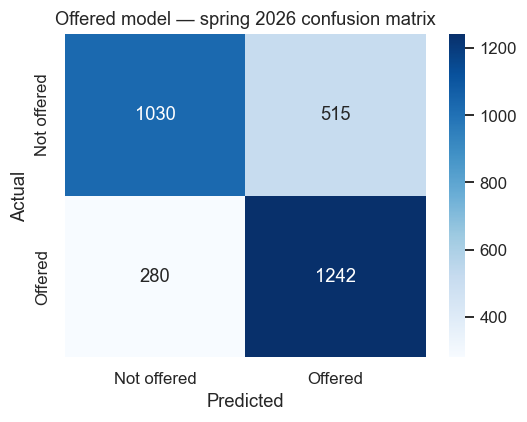

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true_off, y_pred_off)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not offered','Offered'],
            yticklabels=['Not offered','Offered'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Offered model — {TEST_TERM_LABEL} confusion matrix')
plt.tight_layout()
plt.savefig(FIG_PATH / 'offered_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

=== CAPACITY (spring 2026) ===
  MAE:  14.59 seats
  RMSE: 33.78 seats
  R²:   0.8857
  Bias: -4.87 seats  (+ = overpredict)


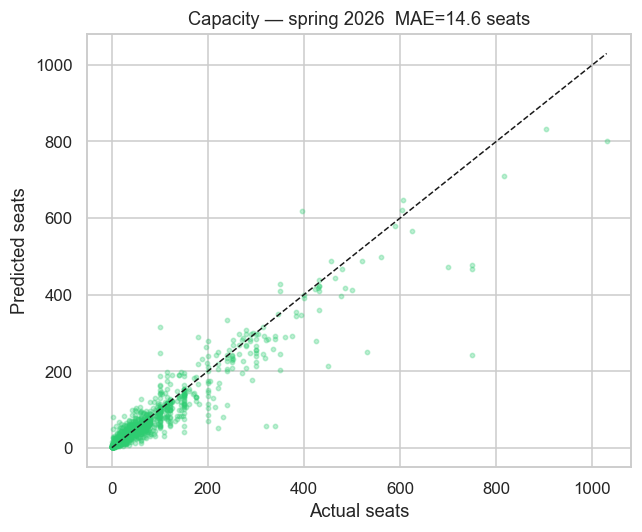

In [7]:
# ── capacity ──────────────────────────────────────────────────────────────────
y_true_cap = capacity_test['total_capacity']
y_pred_cap = capacity_test['pred_capacity']

cap_mae  = mean_absolute_error(y_true_cap, y_pred_cap)
cap_rmse = np.sqrt(mean_squared_error(y_true_cap, y_pred_cap))
cap_r2   = r2_score(y_true_cap, y_pred_cap)
cap_bias = (y_pred_cap - y_true_cap).mean()

print(f'=== CAPACITY ({TEST_TERM_LABEL}) ===')
print(f'  MAE:  {cap_mae:.2f} seats')
print(f'  RMSE: {cap_rmse:.2f} seats')
print(f'  R²:   {cap_r2:.4f}')
print(f'  Bias: {cap_bias:+.2f} seats  (+ = overpredict)')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_true_cap, y_pred_cap, alpha=0.3, s=8, color='#2ecc71')
lim = max(y_true_cap.max(), y_pred_cap.max())
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlabel('Actual seats'); ax.set_ylabel('Predicted seats')
ax.set_title(f'Capacity — {TEST_TERM_LABEL}  MAE={cap_mae:.1f} seats')
plt.tight_layout()
plt.savefig(FIG_PATH / 'capacity_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

=== ENROLLMENT (spring 2026) ===
  MAE:  11.85 students
  RMSE: 24.13 students
  R²:   0.9059
  Bias: -4.28 students  (+ = overpredict)


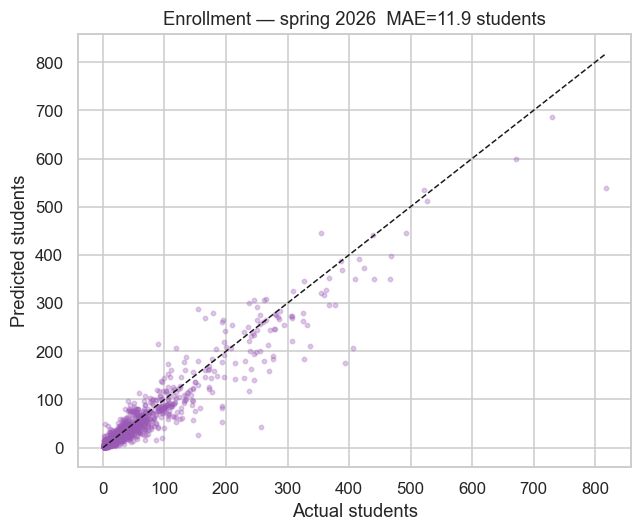

In [8]:
# ── enrollment ────────────────────────────────────────────────────────────────
y_true_enr = enrollment_test['total_enrolled']
y_pred_enr = enrollment_test['pred_enrollment']

enr_mae  = mean_absolute_error(y_true_enr, y_pred_enr)
enr_rmse = np.sqrt(mean_squared_error(y_true_enr, y_pred_enr))
enr_r2   = r2_score(y_true_enr, y_pred_enr)
enr_bias = (y_pred_enr - y_true_enr).mean()

print(f'=== ENROLLMENT ({TEST_TERM_LABEL}) ===')
print(f'  MAE:  {enr_mae:.2f} students')
print(f'  RMSE: {enr_rmse:.2f} students')
print(f'  R²:   {enr_r2:.4f}')
print(f'  Bias: {enr_bias:+.2f} students  (+ = overpredict)')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_true_enr, y_pred_enr, alpha=0.3, s=8, color='#9b59b6')
lim = max(y_true_enr.max(), y_pred_enr.max())
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlabel('Actual students'); ax.set_ylabel('Predicted students')
ax.set_title(f'Enrollment — {TEST_TERM_LABEL}  MAE={enr_mae:.1f} students')
plt.tight_layout()
plt.savefig(FIG_PATH / 'enrollment_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block 5 — System score (0–3)

Score each course 0–3: +1 for each model that was correct simultaneously.  
This is what a real user experiences — partial credit for getting some predictions right.

In [9]:
# merge all predictions onto one table using ml_course_id
# only rows that appear in all three (offered=1 rows with capacity+enrollment targets)
joint = capacity_test[['ml_course_id', 'total_capacity', 'pred_capacity']].merge(
    enrollment_test[['ml_course_id', 'total_enrolled', 'pred_enrollment']],
    on='ml_course_id'
)
joint = joint.merge(
    offered_test[offered_test['offered'] == 1][['ml_course_id', 'offered', 'pred_offered', 'pred_offered_prob']],
    on='ml_course_id'
)

print(f'Joint rows (all three scoreable): {len(joint):,}')

# score offered: exact match
joint['correct_offered'] = (joint['pred_offered'] == joint['offered']).astype(int)

# score capacity: within ABS seats OR REL% — whichever is more lenient
cap_err = (joint['pred_capacity'] - joint['total_capacity']).abs()
joint['correct_capacity'] = (
    (cap_err <= CAPACITY_ABS) | (cap_err / joint['total_capacity'].clip(lower=1) <= CAPACITY_REL)
).astype(int)

# score enrollment: same logic
enr_err = (joint['pred_enrollment'] - joint['total_enrolled']).abs()
joint['correct_enrollment'] = (
    (enr_err <= ENROLLMENT_ABS) | (enr_err / joint['total_enrolled'].clip(lower=1) <= ENROLLMENT_REL)
).astype(int)

joint['system_score'] = joint['correct_offered'] + joint['correct_capacity'] + joint['correct_enrollment']

print(f'\nTolerance thresholds:')
print(f'  Capacity:   within {CAPACITY_ABS} seats OR {int(CAPACITY_REL*100)}% of actual')
print(f'  Enrollment: within {ENROLLMENT_ABS} students OR {int(ENROLLMENT_REL*100)}% of actual')

Joint rows (all three scoreable): 1,522

Tolerance thresholds:
  Capacity:   within 10 seats OR 20% of actual
  Enrollment: within 10 students OR 20% of actual


System score distribution (spring 2026):
  3/3 — Fully correct: 800 courses  (52.6%)
  2/3 — One wrong: 460 courses  (30.2%)
  1/3 — Two wrong: 217 courses  (14.3%)
  0/3 — All wrong: 45 courses  (3.0%)


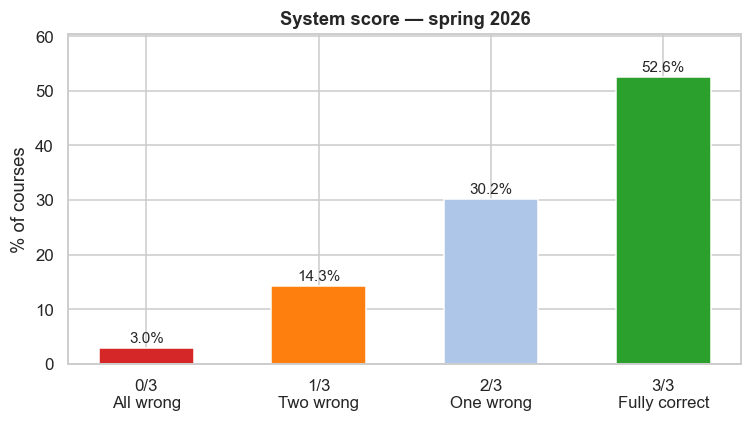


Individual error rates:
  Offered wrong:    18.4%
  Capacity wrong:   25.3%
  Enrollment wrong: 23.9%


In [10]:
score_counts = joint['system_score'].value_counts().sort_index()
score_pct    = score_counts / len(joint) * 100

labels = {3: '3/3 — Fully correct', 2: '2/3 — One wrong', 1: '1/3 — Two wrong', 0: '0/3 — All wrong'}
print(f'System score distribution ({TEST_TERM_LABEL}):')
for score in [3, 2, 1, 0]:
    n   = score_counts.get(score, 0)
    pct = score_pct.get(score, 0)
    print(f'  {labels[score]}: {n:,} courses  ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
score_labels = ['0/3\nAll wrong', '1/3\nTwo wrong', '2/3\nOne wrong', '3/3\nFully correct']
bar_colors   = ['#d62728', '#ff7f0e', '#aec7e8', '#2ca02c']
values       = [score_pct.get(s, 0) for s in [0, 1, 2, 3]]

bars = ax.bar(score_labels, values, color=bar_colors, width=0.55, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('% of courses')
ax.set_title(f'System score — {TEST_TERM_LABEL}', fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.savefig(FIG_PATH / 'system_score.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Individual error rates:')
print(f'  Offered wrong:    {(joint["correct_offered"]==0).mean()*100:.1f}%')
print(f'  Capacity wrong:   {(joint["correct_capacity"]==0).mean()*100:.1f}%')
print(f'  Enrollment wrong: {(joint["correct_enrollment"]==0).mean()*100:.1f}%')

---
## Block 6 — Conditional evaluations

- **C1** — capacity accuracy, given offered was correct
- **C2** — enrollment accuracy, given capacity was within tolerance
- **C3** — enrollment accuracy, given offered was correct

In [11]:
# C1 — capacity given offered correct
c1 = joint[joint['correct_offered'] == 1]
c1_cap_acc  = c1['correct_capacity'].mean() * 100
c1_cap_mae  = (c1['pred_capacity'] - c1['total_capacity']).abs().mean()
c1_cap_bias = (c1['pred_capacity'] - c1['total_capacity']).mean()

print(f'C1 — Capacity given offered correct ({len(c1):,} rows):')
print(f'  Within tolerance: {c1_cap_acc:.1f}%')
print(f'  MAE:              {c1_cap_mae:.1f} seats')
print(f'  Bias:             {c1_cap_bias:+.1f} seats')
print()

cap_err_c1 = (c1['pred_capacity'] - c1['total_capacity']).abs()
print('  Capacity error buckets (given offered correct):')
for threshold in [5, 10, 20, 50]:
    pct = (cap_err_c1 <= threshold).mean() * 100
    print(f'    within {threshold:>2} seats: {pct:.1f}%')

C1 — Capacity given offered correct (1,242 rows):
  Within tolerance: 74.6%
  MAE:              15.4 seats
  Bias:             -4.8 seats

  Capacity error buckets (given offered correct):
    within  5 seats: 50.4%
    within 10 seats: 65.5%
    within 20 seats: 79.3%
    within 50 seats: 93.2%


In [12]:
# C2 — enrollment given capacity correct
c2 = joint[joint['correct_capacity'] == 1]
c2_enr_acc  = c2['correct_enrollment'].mean() * 100
c2_enr_mae  = (c2['pred_enrollment'] - c2['total_enrolled']).abs().mean()
c2_enr_bias = (c2['pred_enrollment'] - c2['total_enrolled']).mean()

print(f'C2 — Enrollment given capacity correct ({len(c2):,} rows):')
print(f'  Within tolerance: {c2_enr_acc:.1f}%')
print(f'  MAE:              {c2_enr_mae:.1f} students')
print(f'  Bias:             {c2_enr_bias:+.1f} students')
print()

# C3 — enrollment given offered correct
c3 = joint[joint['correct_offered'] == 1]
c3_enr_acc  = c3['correct_enrollment'].mean() * 100
c3_enr_mae  = (c3['pred_enrollment'] - c3['total_enrolled']).abs().mean()
c3_enr_bias = (c3['pred_enrollment'] - c3['total_enrolled']).mean()

print(f'C3 — Enrollment given offered correct ({len(c3):,} rows):')
print(f'  Within tolerance: {c3_enr_acc:.1f}%')
print(f'  MAE:              {c3_enr_mae:.1f} students')
print(f'  Bias:             {c3_enr_bias:+.1f} students')

C2 — Enrollment given capacity correct (1,137 rows):
  Within tolerance: 85.8%
  MAE:              8.0 students
  Bias:             -2.7 students

C3 — Enrollment given offered correct (1,242 rows):
  Within tolerance: 77.1%
  MAE:              12.2 students
  Bias:             -4.1 students


Enrollment accuracy summary:
  Unconditional:               76.1%
  Given offered correct  (C3): 77.1%
  Given capacity correct (C2): 85.8%


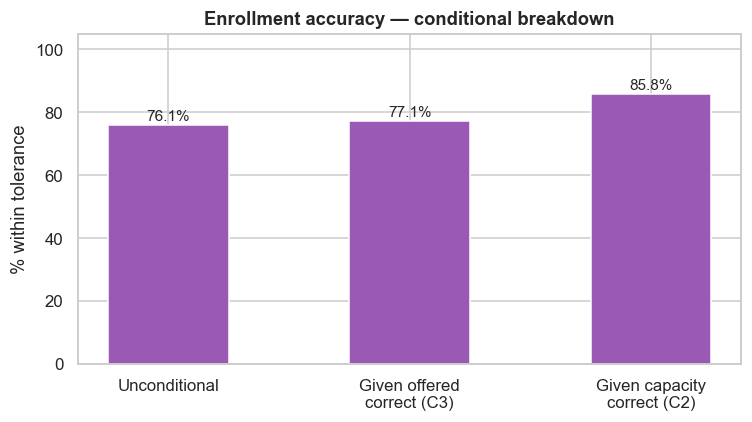

In [13]:
enr_unconditional = joint['correct_enrollment'].mean() * 100

print('Enrollment accuracy summary:')
print(f'  Unconditional:               {enr_unconditional:.1f}%')
print(f'  Given offered correct  (C3): {c3_enr_acc:.1f}%')
print(f'  Given capacity correct (C2): {c2_enr_acc:.1f}%')

conditions = ['Unconditional', 'Given offered\ncorrect (C3)', 'Given capacity\ncorrect (C2)']
enr_accs   = [enr_unconditional, c3_enr_acc, c2_enr_acc]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(conditions, enr_accs, color='#9b59b6', edgecolor='white', width=0.5)
for bar, val in zip(bars, enr_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('% within tolerance')
ax.set_title('Enrollment accuracy — conditional breakdown', fontweight='bold')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(FIG_PATH / 'enrollment_conditional.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block 7 — Summary + write eval_results.json

In [14]:
print('=' * 55)
print(f'SFU COURSE PREDICTOR — EVAL ({TEST_TERM_LABEL.upper()})')
print('=' * 55)
print()
print('INDIVIDUAL MODEL PERFORMANCE:')
print(f'  Offered    (GB)  AUC:  {off_metrics["auc"]:.4f}   Accuracy: {off_metrics["accuracy"]:.4f}')
print(f'  Capacity   (RF)  MAE:  {cap_mae:.2f} seats    R²: {cap_r2:.4f}')
print(f'  Enrollment (RF)  MAE:  {enr_mae:.2f} students  R²: {enr_r2:.4f}')
print()
print('SYSTEM PERFORMANCE (all 3 simultaneous):')
for score in [3, 2, 1, 0]:
    n   = score_counts.get(score, 0)
    pct = score_pct.get(score, 0)
    print(f'  {labels[score]}: {n:,} ({pct:.1f}%)')

SFU COURSE PREDICTOR — EVAL (SPRING 2026)

INDIVIDUAL MODEL PERFORMANCE:
  Offered    (GB)  AUC:  0.8644   Accuracy: 0.7408
  Capacity   (RF)  MAE:  14.59 seats    R²: 0.8857
  Enrollment (RF)  MAE:  11.85 students  R²: 0.9059

SYSTEM PERFORMANCE (all 3 simultaneous):
  3/3 — Fully correct: 800 (52.6%)
  2/3 — One wrong: 460 (30.2%)
  1/3 — Two wrong: 217 (14.3%)
  0/3 — All wrong: 45 (3.0%)


In [15]:
eval_results = {
    'test_term':    TEST_TERM_LABEL,
    'generated_at': str(date.today()),
    'offered': {
        'auc':       off_metrics['auc'],
        'f1':        off_metrics['f1'],
        'accuracy':  off_metrics['accuracy'],
        'precision': off_metrics['precision'],
        'recall':    off_metrics['recall'],
    },
    'capacity': {
        'mae':  round(cap_mae, 2),
        'rmse': round(cap_rmse, 2),
        'r2':   round(cap_r2, 4),
        'bias': round(float(cap_bias), 2),
    },
    'enrollment': {
        'mae':  round(enr_mae, 2),
        'rmse': round(enr_rmse, 2),
        'r2':   round(enr_r2, 4),
        'bias': round(float(enr_bias), 2),
    },
    'system': {
        'fully_correct_pct': round(float(score_pct.get(3, 0)), 1),
        'one_wrong_pct':     round(float(score_pct.get(2, 0)), 1),
        'two_wrong_pct':     round(float(score_pct.get(1, 0)), 1),
        'all_wrong_pct':     round(float(score_pct.get(0, 0)), 1),
    }
}

out_path = MODELS_PATH / 'eval_results.json'
with open(out_path, 'w') as f:
    json.dump(eval_results, f, indent=2)

print(f'Saved → {out_path}')
print(json.dumps(eval_results, indent=2))

Saved → ..\models\eval_results.json
{
  "test_term": "spring 2026",
  "generated_at": "2026-05-14",
  "offered": {
    "auc": 0.8644,
    "f1": 0.7575,
    "accuracy": 0.7408,
    "precision": 0.7069,
    "recall": 0.816
  },
  "capacity": {
    "mae": 14.59,
    "rmse": 33.78,
    "r2": 0.8857,
    "bias": -4.87
  },
  "enrollment": {
    "mae": 11.85,
    "rmse": 24.13,
    "r2": 0.9059,
    "bias": -4.28
  },
  "system": {
    "fully_correct_pct": 52.6,
    "one_wrong_pct": 30.2,
    "two_wrong_pct": 14.3,
    "all_wrong_pct": 3.0
  }
}
